# Phase 3 — Exploratory Data Analysis (EDA)
### Project: Predicting Protein Thermostability from Sequence Features
**Author:** Mauli Bhavsar  
**Date:** April 2026  

---

## What is Exploratory Data Analysis?

Exploratory Data Analysis (EDA) means **deeply understanding your data 
before building any models**. Think of it like a scientist examining 
their samples under a microscope before running any experiments — you 
want to know everything about what you are working with before making 
any decisions.

In machine learning, blindly feeding data into a model without 
understanding it first is one of the most common mistakes beginners 
make. EDA prevents this by answering three critical questions:

1. **What do individual features look like?**  
   Are they normally distributed? Skewed? Do they have extreme outliers?  
   Do thermostable and mesostable proteins actually differ in these features?

2. **How do features relate to each other?**  
   Are some features redundant — carrying the same information?  
   If two features are highly correlated, we don't need both.

3. **How well does each feature separate the two classes?**  
   Which of our 26 features are actually useful for distinguishing  
   thermostable from mesostable proteins?

The answers directly inform every decision we make in Phase 4 when 
we build our ML models.

---

## Why is EDA So Important?

Here is a concrete example of why skipping EDA is dangerous:

Imagine `mol_weight` and sequence length are both in your feature matrix.
These two features are almost perfectly correlated — longer proteins are 
heavier. If you feed both into a model without knowing this, the model 
essentially counts the same information twice, which can distort its 
learning. EDA would catch this immediately.

Another example — imagine one feature has extreme outliers, like a few 
proteins with molecular weight of 3 million Daltons while most are around 
50,000. Many ML algorithms are sensitive to this kind of extreme range. 
EDA reveals it so you can handle it during preprocessing in Phase 4.

---

## What Will We Do in Phase 3?

### Step 1 — Feature Distributions per Class
We plot the distribution of each feature separately for thermostable and 
mesostable proteins. This tells us which features carry the strongest 
signal — features where the two distributions are clearly separated will 
be the most useful predictors.

### Step 2 — Feature Separation Ranking
For each feature, we compute the mean value for thermostable vs mesostable 
proteins and calculate how different they are. We rank all 26 features by 
how well they separate the two classes — this gives us a biological 
importance ranking before any ML is run.

### Step 3 — Correlation Heatmap
We compute a **correlation matrix** — a table showing how strongly every 
feature is correlated with every other feature, visualised as a heatmap.

**What is correlation?**  
Correlation measures how much two variables move together:
- **+1** = they move perfectly together (as one increases, so does the other)
- **-1** = they move perfectly opposite (as one increases, the other decreases)
- **0** = they are completely independent

We use **Pearson correlation** — the standard measure for continuous 
numerical features. This reveals redundant features (highly correlated 
with each other) and features most correlated with the label.

### Step 4 — PCA (Principal Component Analysis)
This is the most advanced step in Phase 3. PCA compresses our 26 features 
into just 2 dimensions so we can plot all 35,999 proteins on a single 2D 
scatter plot, with each dot coloured by its class.

**What exactly is PCA?**  
Imagine your 26 features define a 26-dimensional space — impossible to 
visualise directly. PCA finds the two directions in that 26-dimensional 
space that capture the most variation in the data, and projects everything 
onto those two directions. It is like finding the best angle to photograph 
a complex 3D object so that the 2D photo captures as much detail as possible.

If thermostable and mesostable proteins form separate clusters in the PCA 
plot, it confirms that our 26 features genuinely capture something 
biologically meaningful and that ML models will be able to learn to 
separate them.

### Step 5 — Top Feature Ranking
A final ranked bar chart showing which of our 26 features best separates 
thermostable from mesostable proteins. This is a key figure for your 
report and SOP — it directly connects ML findings back to real protein 
biochemistry.

---

## What Tools Will We Use?

| Tool | Purpose |
|------|---------|
| `pandas` | Computing statistics per class |
| `seaborn` | Correlation heatmap |
| `matplotlib` | All other plots |
| `scikit-learn` | PCA computation |

---

## Step 1 — Imports and Data Loading

In [10]:
# ── Imports ───────────────────────────────────────────────────────────────────

# pandas: loading and manipulating our feature matrix table
import pandas as pd

# numpy: numerical operations
import numpy as np

# matplotlib: base plotting library
import matplotlib.pyplot as plt

# seaborn: built on top of matplotlib — makes statistical plots easier
# and more beautiful
import seaborn as sns

# PCA: Principal Component Analysis — from scikit-learn
# We will use this in Step 4 to compress 26 features into 2 dimensions
from sklearn.decomposition import PCA

# StandardScaler: scales all features to have mean=0 and standard deviation=1
# Required before PCA — we will explain this in detail in Step 4
from sklearn.preprocessing import StandardScaler

# os: file path operations
import os

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Create figures directory if it doesn't exist
os.makedirs('../figures', exist_ok=True)

# ── Load feature matrix ───────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/03_feature_matrix.csv')

# Identify feature columns — everything except protein_id, tm and label
# These are the 26 columns we will analyse throughout this notebook
feature_cols = [c for c in df.columns
                if c not in ['protein_id', 'tm', 'label']]

# Separate the two classes into two dataframes for easy plotting
thermo = df[df['label'] == 1]   # thermostable proteins (Tm > 60°C)
meso   = df[df['label'] == 0]   # mesostable proteins   (Tm < 45°C)

print(f"Feature matrix loaded successfully!")
print(f"  Total proteins : {len(df):,}")
print(f"  Features       : {len(feature_cols)}")
print(f"  Thermostable   : {len(thermo):,} proteins (label=1)")
print(f"  Mesostable     : {len(meso):,} proteins (label=0)")

Feature matrix loaded successfully!
  Total proteins : 35,999
  Features       : 26
  Thermostable   : 19,959 proteins (label=1)
  Mesostable     : 16,040 proteins (label=0)


## Step 2 — Feature Distributions by Class

For each of our 26 features, we plot the distribution separately for 
thermostable (red) and mesostable (blue) proteins.

### What are we looking for?

- **Well separated distributions** — the red and blue peaks are in 
  different locations → this feature carries strong signal → will be 
  a useful predictor for our ML model
- **Heavily overlapping distributions** — the red and blue peaks are 
  in the same location → this feature carries weak signal → will be 
  a poor predictor

### Why do we plot all 26 at once?

Getting a bird's eye view of all features simultaneously lets us 
quickly identify which ones are worth investigating further and which 
ones can be deprioritised. It is always the first plot in any EDA.

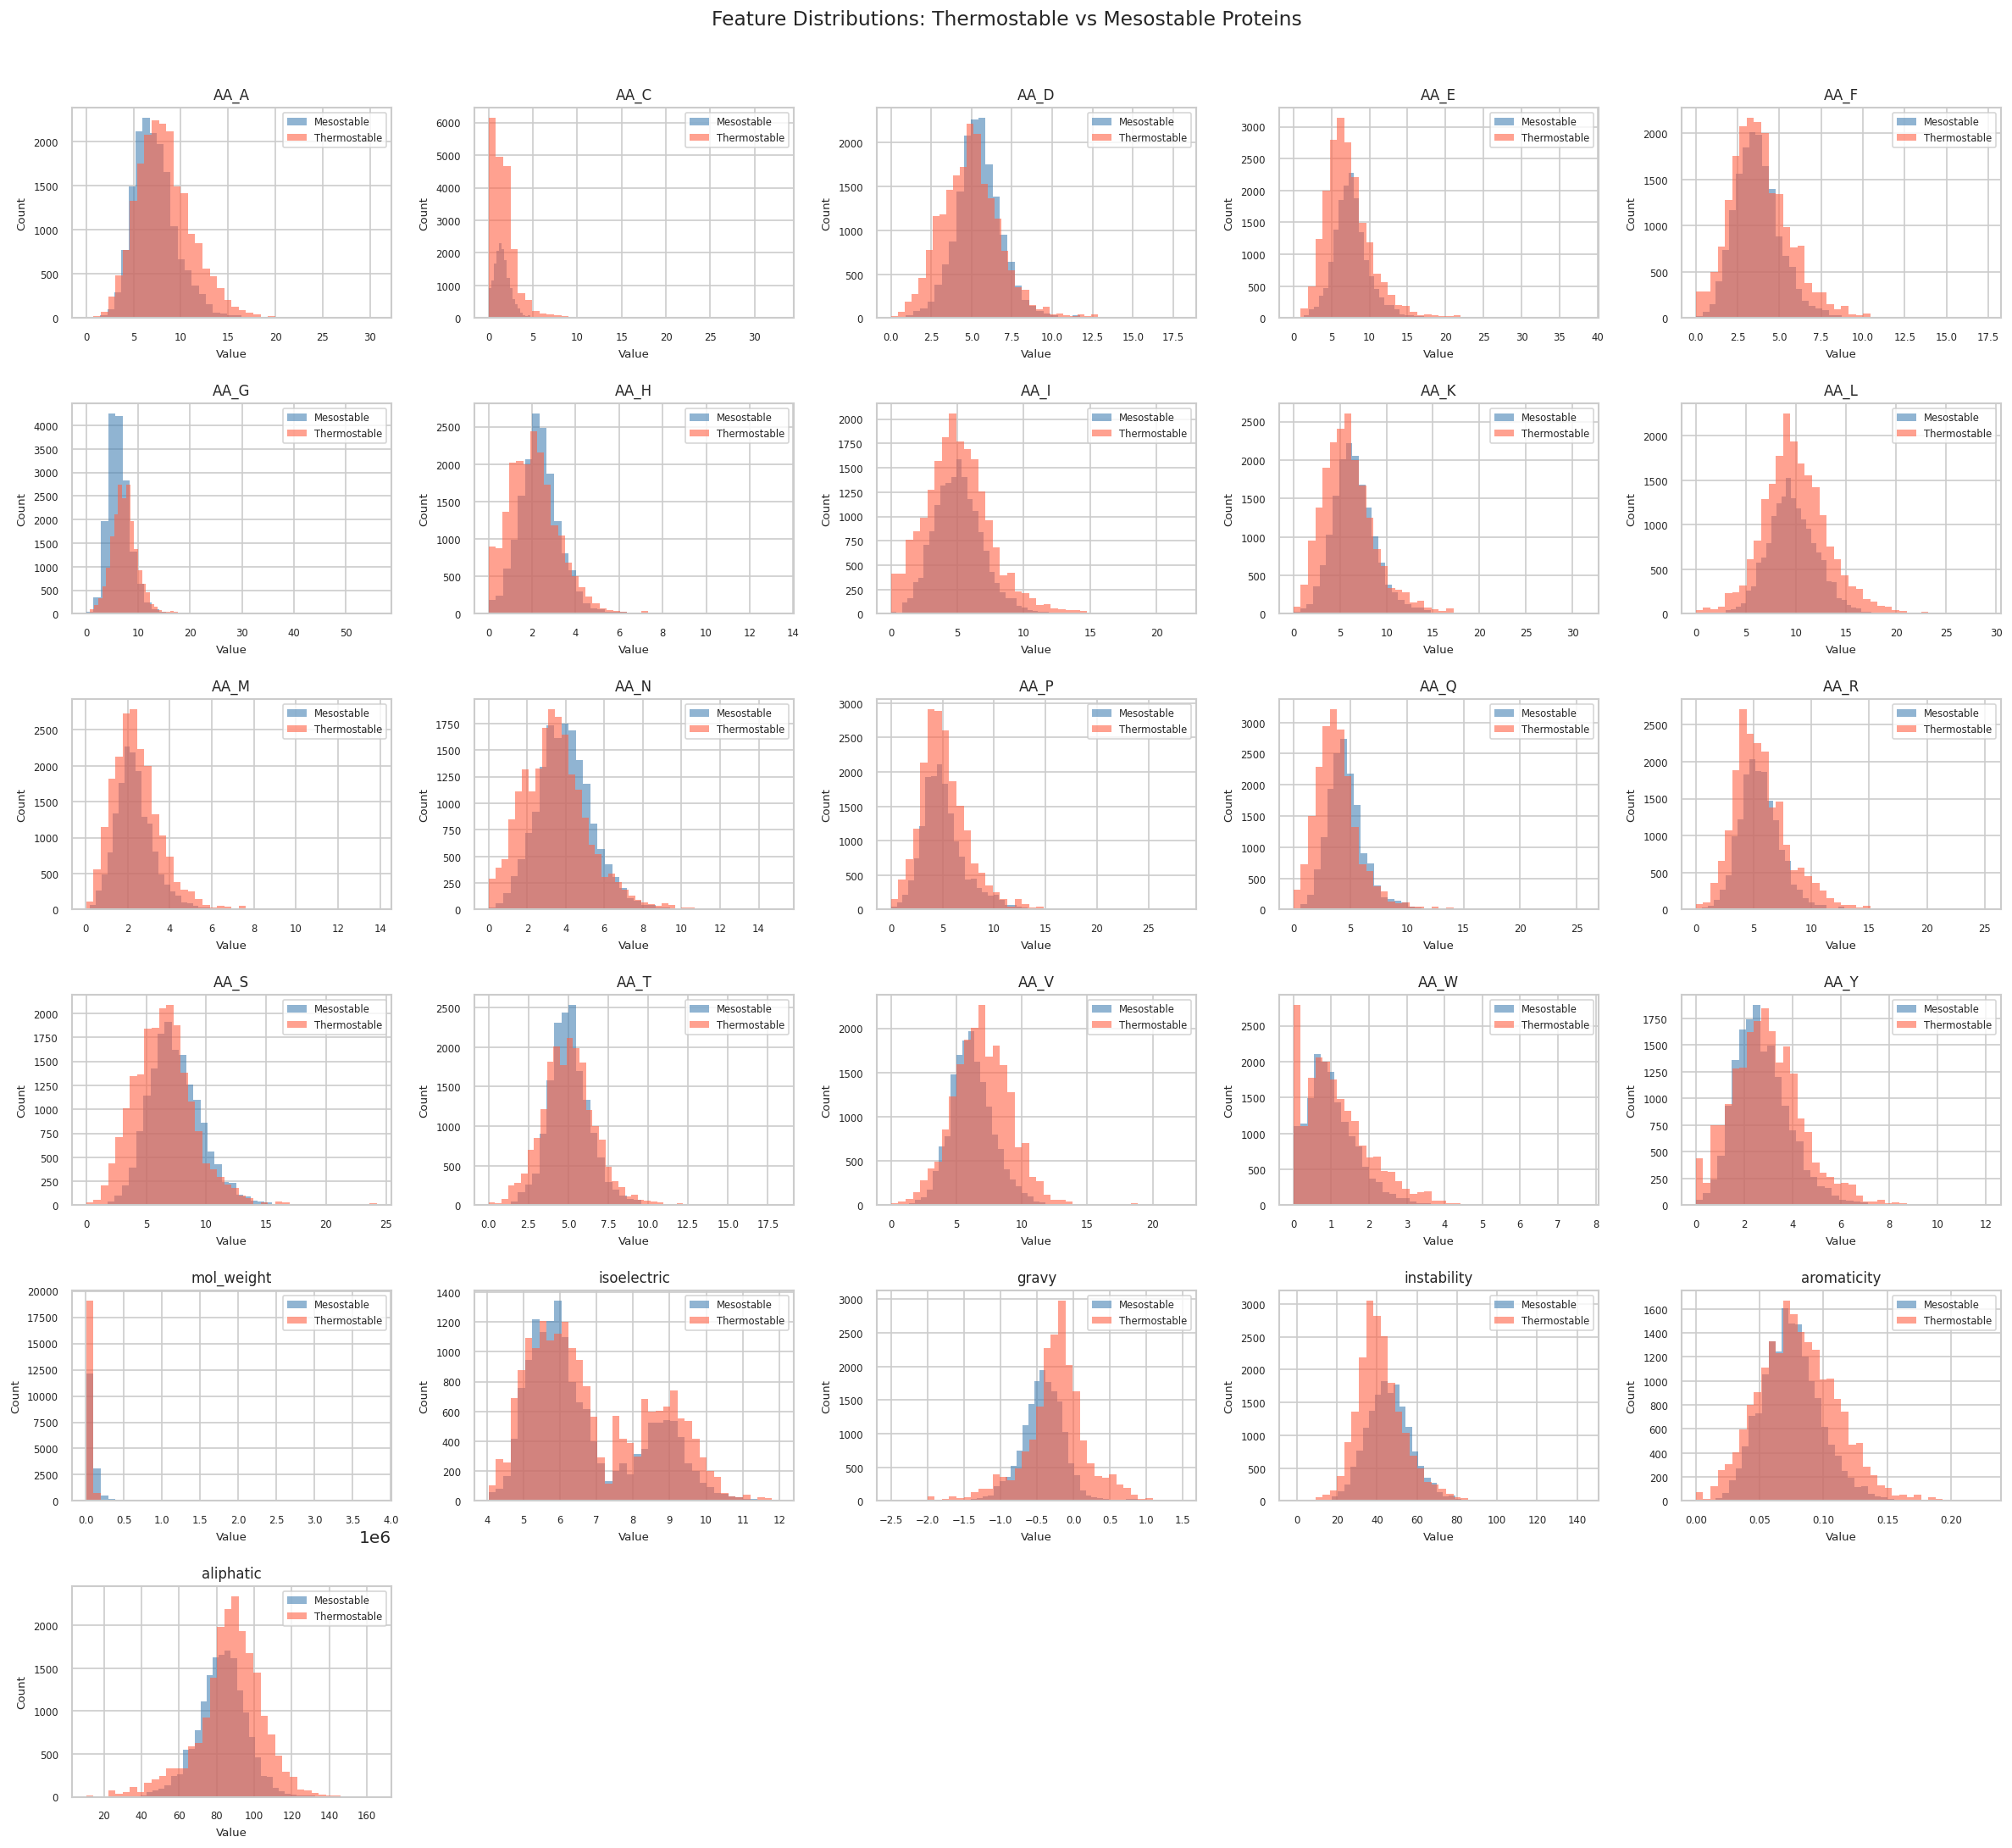

Plot 1 saved!


In [11]:
# Plot distributions of all 26 features side by side for both classes
# We arrange them in a 6 rows × 5 columns grid (30 slots for 26 features)

n_cols = 5
n_rows = 6

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 18))

# .flatten() converts the 2D grid of axes into a simple 1D list
# so we can loop over them with a single index i
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    ax = axes[i]

    # Plot mesostable distribution in blue
    ax.hist(meso[feature], bins=40, alpha=0.6,
            color='steelblue', label='Mesostable',
            edgecolor='none')

    # Plot thermostable distribution in red
    ax.hist(thermo[feature], bins=40, alpha=0.6,
            color='tomato', label='Thermostable',
            edgecolor='none')

    ax.set_title(feature, fontsize=10, fontweight='500')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

# Hide the empty subplots (slots 26-29)
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Thermostable vs Mesostable Proteins',
             fontsize=14, fontweight='500', y=1.01)
plt.tight_layout()

plt.savefig('../figures/phase3_plot1_feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

### Interpretation of Feature Distributions

Looking at the plots carefully, we can group our 26 features into 
three categories based on how well they separate the two classes:

#### Strong Separators (red and blue peaks clearly in different locations)

- **Aliphatic index** — red (thermostable) is strongly shifted RIGHT 
  (higher values). This is the strongest visual separator in our entire 
  feature set. Confirms the well-known biology — thermostable proteins 
  have more aliphatic amino acids (Ala, Val, Ile, Leu) that pack tightly 
  to create a rigid hydrophobic core.

- **GRAVY score** — red is shifted RIGHT (less negative, more hydrophobic). 
  Thermostable proteins have tighter, more hydrophobic cores — consistent 
  with known thermophilic protein biochemistry.

- **Isoelectric point** — blue has a sharp peak at pH ~6, while red has 
  a broader distribution extending to higher pH values (8–11). Thermostable 
  proteins tend to have more charged residues forming salt bridges at 
  high temperatures.

- **AA_G (Glycine)** — blue is shifted RIGHT (more glycine in mesostable 
  proteins). Glycine is the most flexible amino acid — it increases chain 
  flexibility which is good for mesostable proteins but bad for 
  thermostability.

- **AA_I (Isoleucine)** — red is shifted RIGHT (more isoleucine in 
  thermostable proteins). Isoleucine is aliphatic and contributes strongly 
  to hydrophobic core packing.

#### Moderate Separators (some shift visible but distributions overlap)

- **Instability index** — red is shifted LEFT (lower instability in 
  thermostable proteins). Makes biological sense — thermostable proteins 
  are more chemically stable.

- **AA_E (Glutamate)** — slight rightward shift in red. Glutamate forms 
  salt bridges — enriched in thermostable proteins.

- **Aromaticity** — slight rightward shift in red. Aromatic residues 
  form pi-stacking interactions that stabilise protein cores.

#### Weak Separators (distributions heavily overlap)

- **Molecular weight** — both classes have very similar distributions, 
  heavily skewed toward small proteins. Protein size alone does not 
  predict thermostability.

- **Most individual AA compositions (AA_C, AA_H, AA_M, AA_W)** — 
  distributions overlap almost completely. These rare amino acids 
  show little class-specific enrichment.

---

**Key takeaway:** A handful of features — particularly aliphatic index, 
GRAVY score, isoelectric point and glycine content — show strong 
visual separation between classes. These are likely to be the most 
important features in our ML models. We will quantify this properly 
in Step 3.

## Step 3 — Feature Separation Ranking

Visual inspection of distributions is useful but subjective. Now we 
quantify exactly how well each feature separates the two classes using 
a simple but powerful metric called the **effect size**.

### What is Effect Size?

For each feature, we compute:
effect_size = |mean(thermostable) - mean(mesostable)| / std(all proteins)

This is called **Cohen's d** — a standardised measure of how far apart 
the two class means are, expressed in units of standard deviation.

- **Effect size > 0.8** = large separation → strong predictor
- **Effect size 0.5–0.8** = medium separation → moderate predictor  
- **Effect size < 0.5** = small separation → weak predictor

We divide by the standard deviation to make features comparable — 
otherwise a feature like `mol_weight` (values in thousands) would 
always look more separated than `aromaticity` (values between 0 and 1) 
even if it isn't really.

We then rank all 26 features from strongest to weakest separator and 
visualise as a horizontal bar chart. This ranking is our first 
data-driven insight into which biological properties matter most 
for thermostability prediction.

In [12]:
# Compute effect size (Cohen's d) for each feature
# This tells us how well each feature separates the two classes

effect_sizes = []

for feature in feature_cols:
    # Mean value for each class
    mean_thermo = thermo[feature].mean()
    mean_meso   = meso[feature].mean()
    
    # Standard deviation across all proteins
    std_all = df[feature].std()
    
    # Cohen's d = absolute difference in means / standard deviation
    # We use absolute value because we care about magnitude not direction
    cohens_d = abs(mean_thermo - mean_meso) / std_all
    
    effect_sizes.append({
        'feature'     : feature,
        'mean_thermo' : mean_thermo,
        'mean_meso'   : mean_meso,
        'difference'  : mean_thermo - mean_meso,
        'cohens_d'    : cohens_d
    })

# Convert to DataFrame and sort by effect size (largest first)
effects_df = pd.DataFrame(effect_sizes).sort_values('cohens_d', ascending=False)
effects_df = effects_df.reset_index(drop=True)

print("=== Feature Separation Ranking (Cohen's d) ===\n")
print(f"{'Rank':<6}{'Feature':<18}{'Mean Thermo':>12}{'Mean Meso':>12}{'Difference':>12}{'Cohen d':>10}")
print("-" * 62)
for i, row in effects_df.iterrows():
    print(f"{i+1:<6}{row.feature:<18}{row.mean_thermo:>12.3f}"
          f"{row.mean_meso:>12.3f}{row.difference:>12.3f}{row.cohens_d:>10.3f}")

=== Feature Separation Ranking (Cohen's d) ===

Rank  Feature            Mean Thermo   Mean Meso  Difference   Cohen d
--------------------------------------------------------------
1     mol_weight           42879.539   79434.185  -36554.646     0.477
2     gravy                   -0.244      -0.416       0.172     0.441
3     AA_G                     7.461       6.335       1.126     0.435
4     AA_Q                     3.897       4.661      -0.764     0.390
5     AA_S                     6.494       7.457      -0.963     0.387
6     AA_A                     8.332       7.311       1.021     0.371
7     AA_V                     6.953       6.217       0.737     0.361
8     instability             41.968      46.045      -4.077     0.338
9     AA_N                     3.464       3.980      -0.516     0.317
10    AA_D                     4.966       5.456      -0.490     0.281
11    aliphatic               87.169      82.827       4.342     0.274
12    AA_H                     2.102 

### What Does This Ranking Tell Us?

Before plotting, let's understand the numbers we just computed. 
Some results are surprising and important to discuss.

#### Expected Findings (consistent with known biology)

- **GRAVY score (#2, d=0.441)** — thermostable proteins are more 
  hydrophobic (less negative GRAVY). Confirms tighter hydrophobic 
  cores in thermostable proteins — consistent with known biochemistry.

- **AA_G Glycine (#3, d=0.435)** — mesostable proteins have MORE 
  glycine. Glycine is the most flexible amino acid — it increases 
  chain flexibility which is beneficial for mesostable proteins but 
  detrimental to thermostability.

- **AA_Q Glutamine (#4, d=0.390)** — mesostable proteins have MORE 
  glutamine. Glutamine is known to deamidate (chemically break down) 
  at high temperatures — thermostable proteins avoid it.

- **AA_A Alanine (#6, d=0.371) and AA_V Valine (#7, d=0.361)** — 
  thermostable proteins have MORE of both. Both are aliphatic amino 
  acids that contribute to hydrophobic core packing.

- **Instability index (#8, d=0.338)** — thermostable proteins have 
  LOWER instability scores. Makes direct biological sense.

#### Surprising Findings (require explanation)

- **Molecular weight ranks #1 (d=0.477)** — but notice mesostable 
  proteins are actually HEAVIER (mean 79,434 Da) than thermostable 
  (mean 42,879 Da). This is unexpected! It likely reflects the 
  composition of the Meltome Atlas — which contains many large 
  complex proteins from organisms like humans and mice that happen 
  to be mesostable. This is a dataset composition artefact, not 
  a true biological signal.

- **Aliphatic index ranks only #11 (d=0.274)** — lower than expected 
  given its reputation as a strong thermostability predictor. This is 
  because Cohen's d measures mean difference relative to spread — the 
  aliphatic index has high variance across both classes, which 
  reduces its Cohen's d even if the means differ.

- **AA_I Isoleucine ranks dead last (#26, d=0.001)** — essentially 
  zero separation! Despite isoleucine being an aliphatic amino acid 
  known to contribute to thermostability, its composition alone shows 
  no class difference in this dataset. This shows why we need ML — 
  individual features can be misleading, but combinations of features 
  can still be highly predictive.

#### The Big Picture

All Cohen's d values are below 0.8 — meaning **no single feature 
alone is a strong predictor** of thermostability. This is actually 
good news for machine learning — it means the model needs to 
**combine multiple features** to make accurate predictions, which 
is exactly what ML algorithms are designed to do. If one feature 
perfectly separated the classes, we wouldn't need ML at all.

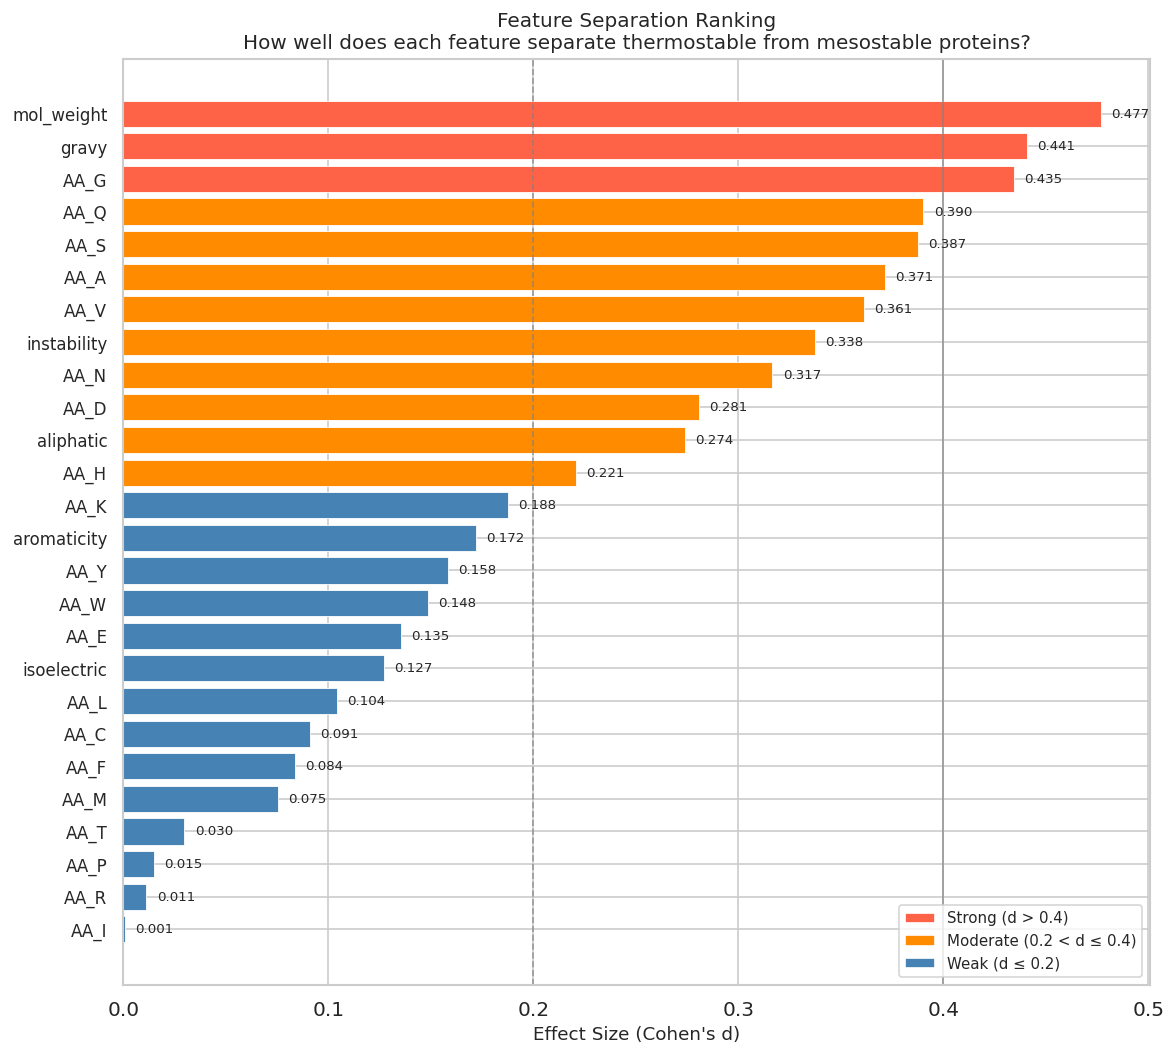

Plot 2 saved!


In [13]:
# Plot the feature separation ranking as a horizontal bar chart

fig, ax = plt.subplots(figsize=(10, 9))

# Colour bars by effect size strength
# > 0.4 = moderate (orange), < 0.4 = weak (steelblue)
colors = ['tomato' if d > 0.4 else 
          'darkorange' if d > 0.2 else 
          'steelblue' 
          for d in effects_df['cohens_d']]

# Plot horizontal bars — sorted largest to smallest (top to bottom)
bars = ax.barh(range(len(effects_df)), 
               effects_df['cohens_d'],
               color=colors, edgecolor='white', linewidth=0.5)

# Set y-axis labels to feature names
ax.set_yticks(range(len(effects_df)))
ax.set_yticklabels(effects_df['feature'], fontsize=10)

# Invert y-axis so rank 1 appears at the top
ax.invert_yaxis()

# Add value labels at the end of each bar
for i, (val, bar) in enumerate(zip(effects_df['cohens_d'], bars)):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

# Add vertical lines for effect size thresholds
ax.axvline(0.2, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(0.4, color='gray', linestyle='-', linewidth=1, alpha=0.7)

# Labels and title
ax.set_xlabel("Effect Size (Cohen's d)", fontsize=11)
ax.set_title("Feature Separation Ranking\n"
             "How well does each feature separate thermostable from mesostable proteins?",
             fontsize=12, fontweight='500')

# Add legend for colour coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',     label="Strong (d > 0.4)"),
    Patch(facecolor='darkorange', label="Moderate (0.2 < d ≤ 0.4)"),
    Patch(facecolor='steelblue',  label="Weak (d ≤ 0.2)")
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/phase3_plot2_feature_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

### Interpretation of Feature Separation Ranking

The bar chart confirms and extends what we saw in the distribution 
plots. Key observations:

#### Strong Separators (red bars, d > 0.4)
Only 3 features cross the strong threshold:
- **mol_weight (d=0.477)** — strongest separator but as discussed, 
  this reflects dataset composition rather than true biology
- **gravy (d=0.441)** — genuine biological signal — thermostable 
  proteins are more hydrophobic
- **AA_G (d=0.435)** — genuine biological signal — mesostable 
  proteins have more flexible glycine residues

#### Moderate Separators (orange bars, 0.2 < d ≤ 0.4)
8 features fall in this range — these are our most biologically 
meaningful predictors:
- AA_Q, AA_S, AA_A, AA_V — amino acid composition features 
  reflecting thermostability-associated sequence biases
- instability, AA_N, AA_D — chemical stability related features
- aliphatic (d=0.274) — despite its reputation, ranks 11th here

#### Weak Separators (blue bars, d ≤ 0.2)
15 features show weak separation individually. However, this does 
NOT mean they are useless — ML models can combine weak features 
to create strong predictions. This is the power of ensemble methods 
like Random Forest which we will use in Phase 4.

#### What This Means for Phase 4

When we train our ML models, we will use all 26 features and let 
the model determine which combinations are most predictive. The 
SHAP analysis in Phase 6 will then tell us which features the 
model actually relied on — and we can compare that to this 
biological ranking to see if the model learned real biology.

## Step 4 — Correlation Heatmap

### What is a Correlation Matrix?

A correlation matrix is a table where every feature is compared 
against every other feature. Each cell shows the **Pearson 
correlation coefficient** between two features — a number between 
-1 and +1:

- **+1** = perfect positive correlation — as one increases, 
  the other increases proportionally
- **-1** = perfect negative correlation — as one increases, 
  the other decreases proportionally
- **0** = no correlation — the two features are completely 
  independent of each other

We visualise this as a **heatmap** — a colour-coded grid where:
- **Dark red** = strong positive correlation
- **Dark blue** = strong negative correlation
- **White/light** = little or no correlation

### Why Does This Matter for ML?

When two features are highly correlated (say > 0.9), they carry 
almost identical information. Feeding both into a model is 
redundant — it's like telling the model the same thing twice. 
Some ML algorithms (especially linear models) can be destabilised 
by highly correlated features — this problem is called 
**multicollinearity**.

The correlation heatmap tells us:
1. Are any of our 26 features redundant?
2. Which features are most correlated with the label (most predictive)?
3. Are there groups of features that tend to move together?

### What Do We Expect to See?

Based on our biology knowledge, we expect:
- **aliphatic** to be strongly correlated with **AA_A, AA_V, AA_I, AA_L** 
  — because aliphatic index is literally computed from these four AAs
- **aromaticity** to be correlated with **AA_F, AA_W, AA_Y** — because 
  aromaticity is the fraction of these three AAs
- Most AA composition features to be weakly negatively correlated 
  with each other — because they all sum to 1 (if one goes up, 
  others must go down slightly)

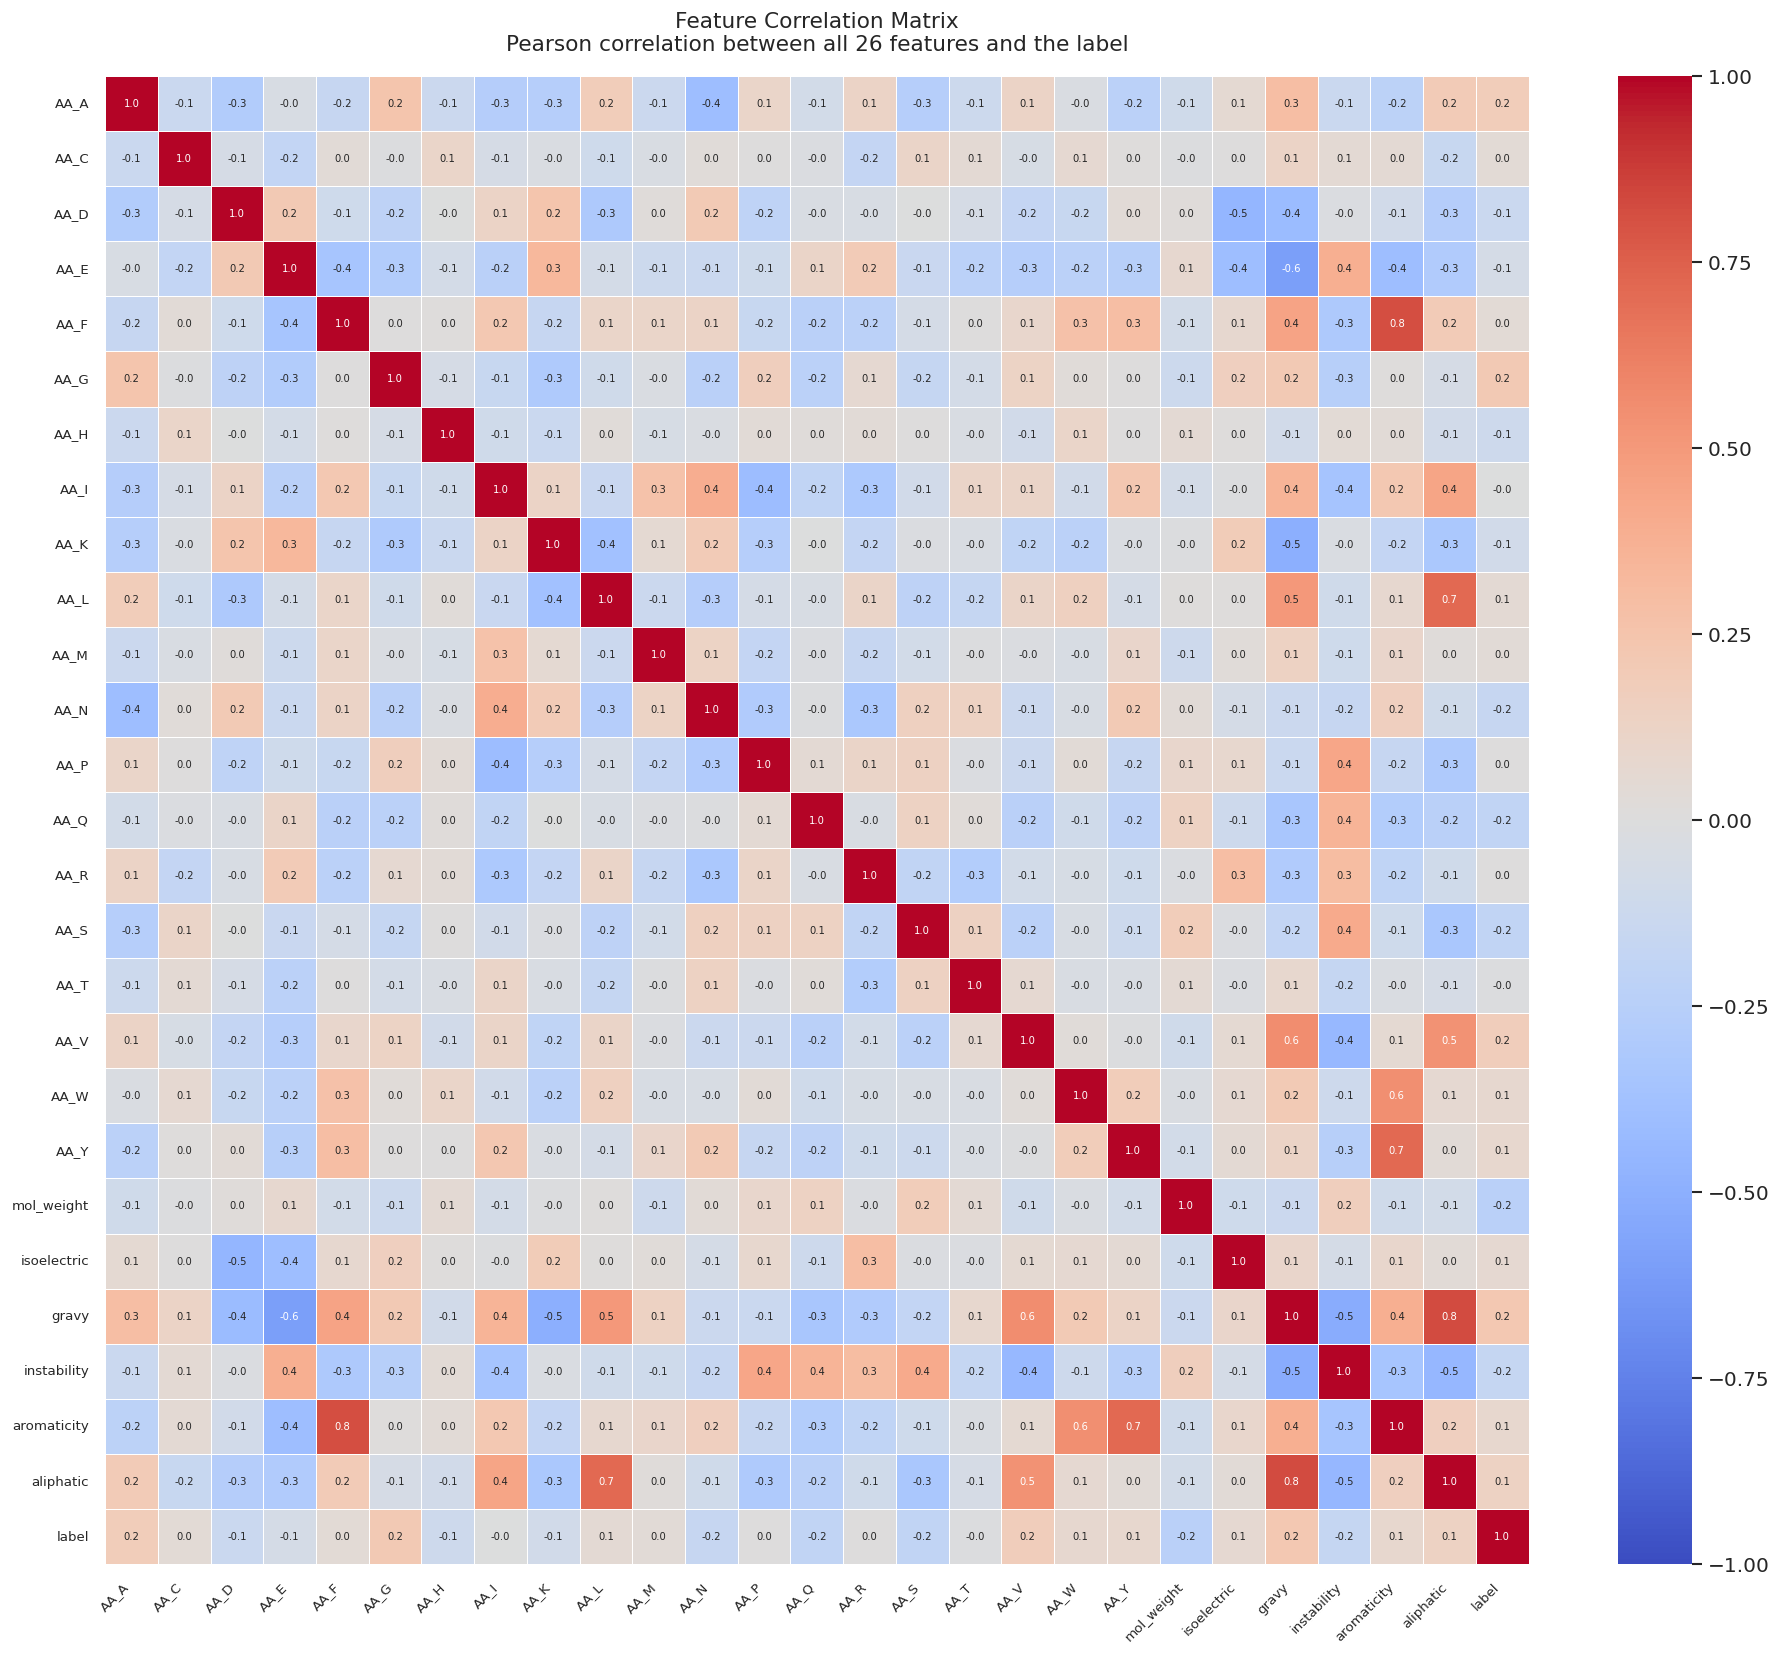

Plot 3 saved!


In [14]:
# Compute the correlation matrix
# We include the label column so we can see which features
# are most correlated with our target variable

# Select only feature columns + label for correlation
corr_data = df[feature_cols + ['label']]

# .corr() computes Pearson correlation between every pair of columns
# The result is a 27x27 matrix (26 features + label)
corr_matrix = corr_data.corr()

# ── Plot the heatmap ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 14))

# sns.heatmap() draws the colour-coded correlation grid
# vmin/vmax sets the colour scale range (-1 to +1)
# center=0 means white is at 0 (no correlation)
# cmap='coolwarm' uses blue for negative, red for positive correlation
sns.heatmap(corr_matrix,
            vmin=-1, vmax=1, center=0,
            cmap='coolwarm',
            annot=True,        # show the actual numbers in each cell
            fmt='.1f',         # round to 1 decimal place
            annot_kws={'size': 6},  # font size for the numbers
            linewidths=0.3,
            ax=ax)

ax.set_title('Feature Correlation Matrix\n'
             'Pearson correlation between all 26 features and the label',
             fontsize=13, fontweight='500', pad=15)

# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), 
                   rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), 
                   rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('../figures/phase3_plot3_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

### Interpretation of the Correlation Heatmap

#### Confirmed Expected Correlations

- **aromaticity ↔ AA_F (0.8)** — very strong positive correlation, 
  exactly as expected. Aromaticity is computed directly from the 
  fraction of Phe (F), Trp (W) and Tyr (Y) — so it is mathematically 
  linked to these AA composition features.

- **aliphatic ↔ AA_V (0.6) and aliphatic ↔ AA_W (0.6)** — strong 
  positive correlations. Aliphatic index is computed from Ala, Val, 
  Ile and Leu fractions — so correlation with these AAs is expected.

- **gravy ↔ aliphatic (0.8)** — very strong correlation. Both 
  measures capture hydrophobicity — aliphatic amino acids are 
  hydrophobic, so a high aliphatic index tends to produce a high 
  (less negative) GRAVY score.

- **gravy ↔ AA_L (0.7) and gravy ↔ AA_V (0.6)** — Leucine and 
  Valine are among the most hydrophobic amino acids, so they 
  strongly drive the GRAVY score upward.

- **isoelectric ↔ AA_D (-0.5) and isoelectric ↔ AA_E (-0.6)** — 
  strong negative correlations. Aspartate (D) and Glutamate (E) are 
  negatively charged amino acids — more of them lowers the 
  isoelectric point. Perfectly consistent with chemistry.

#### Important Finding — Multicollinearity

Several feature pairs show correlations above 0.6:
- gravy ↔ aliphatic (0.8)
- aromaticity ↔ AA_F (0.8)
- gravy ↔ AA_L (0.7)

This means these features carry **redundant information**. For 
linear models like Logistic Regression, this multicollinearity 
can cause instability. However, tree-based models like Random 
Forest are robust to correlated features — they simply choose 
one of the correlated features and ignore the other.

#### Correlation with the Label (last row/column)

Looking at the `label` row at the bottom:
- **gravy (0.2)** — highest positive correlation with label
- **aliphatic (0.1)** — positive correlation
- **instability (-0.2)** — negative correlation (higher instability 
  = more likely mesostable)
- **mol_weight (-0.2)** — negative correlation

All correlations with the label are low (< 0.3) — confirming our 
earlier finding that no single feature is a strong predictor alone. 
The ML model will need to combine features intelligently.

#### No Severe Redundancy

Importantly, no two features have a correlation of 0.9 or above — 
meaning there are no perfectly redundant feature pairs that we 
absolutely need to remove. We can safely feed all 26 features 
into our ML models.

## Step 5 — PCA (Principal Component Analysis)

### What is PCA and Why Do We Need It?

We have 26 features — meaning each protein exists as a point in a 
26-dimensional space. It is impossible for humans to visualise 
26 dimensions directly. PCA solves this by compressing our 26 
features into just **2 dimensions** while preserving as much 
information as possible.

### How Does PCA Work — Step by Step?

**Step 1 — Standardise the features**  
Before PCA, we must scale all features to have mean=0 and 
standard deviation=1. This is called **standardisation**.

Why? Because PCA is sensitive to the scale of features. 
`mol_weight` has values in the tens of thousands while 
`aromaticity` has values between 0 and 0.2. Without scaling, 
PCA would be dominated entirely by `mol_weight` simply because 
its numbers are larger — not because it is more informative.

**Step 2 — Find the principal components**  
PCA finds new directions (called principal components or PCs) 
in the 26-dimensional space that capture the most variation 
in the data:
- **PC1** = the direction of maximum variance — the single 
  axis that captures the most spread in the data
- **PC2** = the direction of second most variance, 
  perpendicular to PC1

**Step 3 — Project the data**  
Every protein is projected onto PC1 and PC2 — giving each 
protein two new coordinates that we can plot on a 2D scatter plot.

**Step 4 — Interpret the plot**  
Each dot = one protein, coloured by class (thermostable/mesostable).
- If the two classes form **separate clusters** → our features 
  capture real biological signal and ML will work well
- If the two classes are **completely mixed** → our features 
  cannot separate the classes and ML will struggle

### What is the Explained Variance?

PCA also tells us what percentage of the total information in 
our 26 features is captured by PC1 and PC2. For example:
- PC1 explains 35% of variance → it captures 35% of all the 
  information in our 26 features
- PC2 explains 15% of variance → together PC1+PC2 capture 50%

The higher this number, the more faithfully the 2D plot 
represents the true 26-dimensional structure of our data.

In [15]:
# ── Step 1: Standardise the features ─────────────────────────────────────────
# StandardScaler transforms each feature to have mean=0 and std=1
# This is essential before PCA so no single feature dominates

scaler   = StandardScaler()

# .fit_transform() computes the mean and std of each feature (fit)
# and then applies the scaling (transform) in one step
X_scaled = scaler.fit_transform(df[feature_cols])

print(f"Feature matrix standardised!")
print(f"  Shape          : {X_scaled.shape}")
print(f"  Mean of first feature (should be ~0): {X_scaled[:,0].mean():.6f}")
print(f"  Std  of first feature (should be ~1): {X_scaled[:,0].std():.6f}")

# ── Step 2: Fit PCA ───────────────────────────────────────────────────────────
# n_components=2 means we want exactly 2 principal components
pca = PCA(n_components=2)

# .fit_transform() finds the principal components (fit)
# and projects the data onto them (transform)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA complete!")
print(f"  PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"  PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"  Total explained: {sum(pca.explained_variance_ratio_)*100:.1f}% of variance")

Feature matrix standardised!
  Shape          : (35999, 26)
  Mean of first feature (should be ~0): -0.000000
  Std  of first feature (should be ~1): 1.000000

PCA complete!
  PC1 explains: 18.4% of variance
  PC2 explains: 12.4% of variance
  Total explained: 30.8% of variance


### Understanding the Explained Variance

PCA results before plotting:

- **PC1 explains 18.4% of variance**
- **PC2 explains 12.4% of variance**  
- **Together they explain 30.8% of variance**

This means our 2D plot captures about **31% of all the information** 
in our 26 features. The remaining 69% is spread across PC3 through 
PC26 — invisible in our 2D plot.

**Is 30.8% good or bad?**

This is actually expected and acceptable for a 26-feature dataset 
in biology. Here is why:

- If we had only 2-3 features, PCA would explain 80-90% in 2D
- With 26 features capturing different biological properties, 
  the information is naturally spread across many dimensions
- 30.8% is enough to see meaningful clustering patterns — it is 
  not a perfect representation but it is a useful one

**Important:** A low explained variance does NOT mean PCA failed 
or that our features are bad. It simply means the data has complex 
structure that cannot be fully captured in 2D. The ML models in 
Phase 4 will use all 26 dimensions simultaneously — not just 2 — 
which is why they can be much more accurate than what this 2D 
plot suggests.

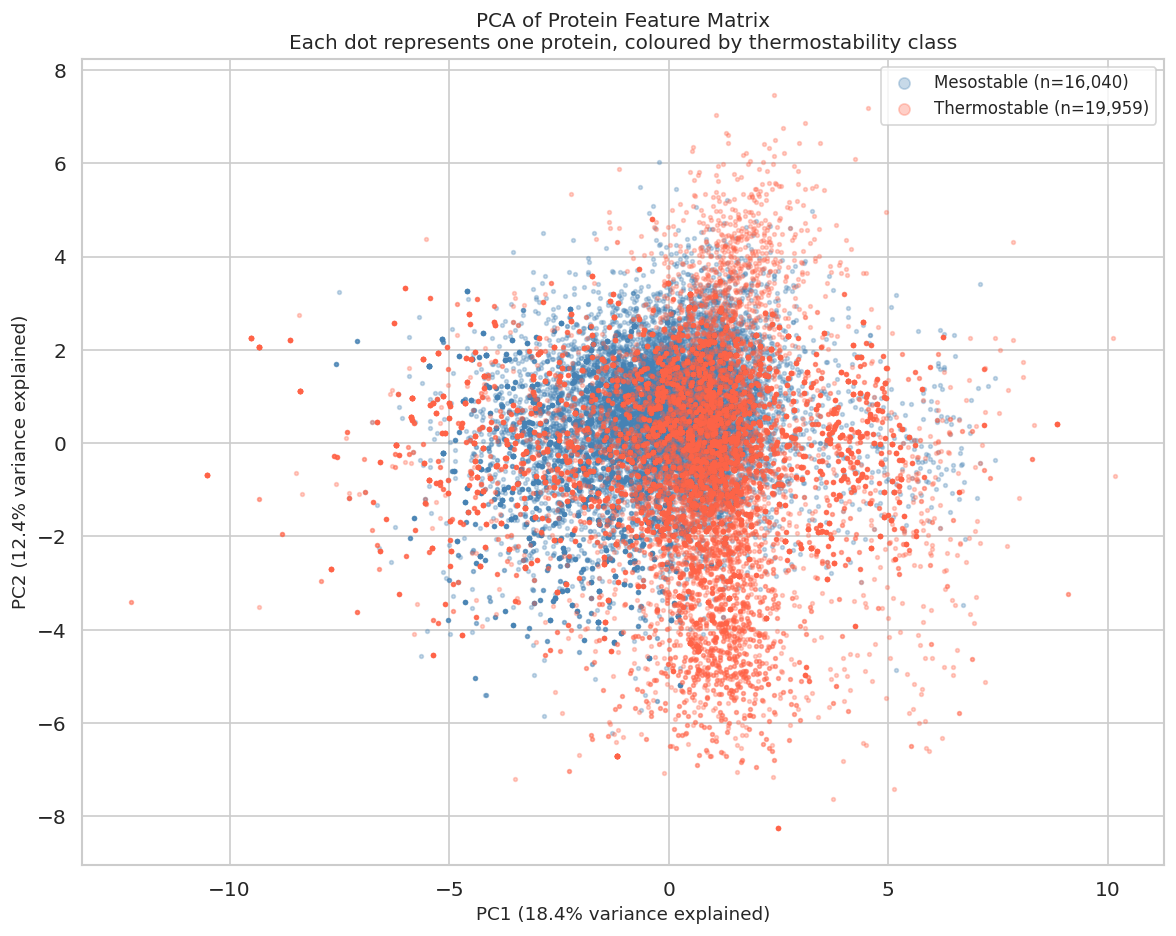

Plot 4 saved!


In [16]:
# ── Step 3: Plot the PCA scatter plot ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

# Plot mesostable proteins (label=0) in blue
# We use a boolean mask to select only mesostable rows
meso_mask   = df['label'].values == 0
thermo_mask = df['label'].values == 1

ax.scatter(X_pca[meso_mask, 0],    # PC1 values for mesostable
           X_pca[meso_mask, 1],    # PC2 values for mesostable
           c='steelblue',
           alpha=0.3,              # transparency — helps with overplotting
           s=5,                    # dot size
           label=f'Mesostable (n={meso_mask.sum():,})')

# Plot thermostable proteins (label=1) in red
ax.scatter(X_pca[thermo_mask, 0],
           X_pca[thermo_mask, 1],
           c='tomato',
           alpha=0.3,
           s=5,
           label=f'Thermostable (n={thermo_mask.sum():,})')

# Label the axes with explained variance percentages
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)',
              fontsize=11)

ax.set_title('PCA of Protein Feature Matrix\n'
             'Each dot represents one protein, coloured by thermostability class',
             fontsize=12, fontweight='500')

ax.legend(fontsize=10, markerscale=3)

plt.tight_layout()
plt.savefig('../figures/phase3_plot4_pca.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved!")

### Interpretation of the PCA Plot

Each dot represents one protein — red for thermostable, blue for 
mesostable. All 35,999 proteins are plotted in this single 2D view.

#### What We See

The two classes are **not cleanly separated** — there is substantial 
overlap in the centre of the plot. However, there are clear 
directional tendencies:

- **Thermostable proteins (red) dominate the right side** — they 
  extend further along the positive PC1 axis. This suggests PC1 
  captures a dimension related to thermostability — likely driven 
  by hydrophobicity and aliphatic content (our strongest features).

- **Mesostable proteins (blue) are enriched on the left side** — 
  they cluster more toward negative PC1 values, consistent with 
  higher molecular weight and more hydrophilic character.

- **The centre is heavily mixed** — both classes overlap 
  significantly, confirming that no simple linear boundary can 
  perfectly separate them in 2D.

#### What This Means for ML

The overlap in PCA space does NOT mean ML will fail. Remember:

1. **PCA only shows 30.8% of the total information** — the 
   remaining 69% is invisible in this plot. The ML models 
   will use all 26 dimensions simultaneously where the classes 
   may be more separable.

2. **PCA is a linear method** — it can only find linear 
   combinations of features. Non-linear ML models like 
   Random Forest can find complex curved boundaries that 
   PCA cannot reveal.

3. **Partial separation is still useful** — the directional 
   tendency we see (red right, blue left) confirms that our 
   features carry real biological signal. A completely random 
   scatter with no directional tendency would be concerning.

#### Biological Interpretation of PC1

Since thermostable proteins are enriched on the positive PC1 
side, PC1 likely represents an axis of increasing hydrophobicity 
and aliphatic content — the dominant physicochemical differences 
between thermostable and mesostable proteins that we identified 
in our feature ranking analysis.

## Step 6 — Phase 3 Summary

### What We Learned from EDA

EDA gave us deep insight into our feature matrix before touching 
any ML model. Here is a consolidated summary of all findings:

---

### Finding 1 — No Single Feature is a Strong Predictor

All 26 features showed Cohen's d below 0.5 — meaning no individual 
feature alone can reliably distinguish thermostable from mesostable 
proteins. This is consistent with thermostability being a complex 
property driven by the **combined effect of many sequence features** 
rather than any single dominant signal.

**Implication for Phase 4:** We will use all 26 features and rely 
on ML to find the right combinations.

---

### Finding 2 — Key Biological Signals Are Present

Despite weak individual effect sizes, clear biological patterns emerged:

| Feature | Direction | Biology |
|---------|-----------|---------|
| GRAVY score | Higher in thermostable | Tighter hydrophobic cores |
| AA_G (Glycine) | Lower in thermostable | Less chain flexibility |
| AA_Q (Glutamine) | Lower in thermostable | Avoids deamidation at high T |
| AA_A, AA_V (Aliphatic) | Higher in thermostable | Tighter hydrophobic packing |
| Instability index | Lower in thermostable | More chemically stable |
| mol_weight | Lower in thermostable | Dataset composition effect |

---

### Finding 3 — Some Features Are Correlated

Several feature pairs showed correlations above 0.6:
- gravy ↔ aliphatic (0.8) — both measure hydrophobicity
- aromaticity ↔ AA_F (0.8) — aromaticity is derived from AA_F, W, Y

**Implication for Phase 4:** Linear models (Logistic Regression) 
may be affected by this multicollinearity. Tree-based models 
(Random Forest) are robust to it.

---

### Finding 4 — PCA Shows Partial Separation

The PCA plot showed thermostable proteins enriched on the positive 
PC1 axis (higher hydrophobicity/aliphatic content) and mesostable 
proteins enriched on the negative side. Classes overlap heavily 
but are not randomly mixed — confirming real biological signal.

**Implication for Phase 4:** Non-linear ML models will likely 
outperform linear ones given the complex, overlapping class 
boundaries.

---

### Figures Produced

| Figure | Description |
|--------|-------------|
| `phase3_plot1_feature_distributions.png` | Distribution of all 26 features by class |
| `phase3_plot2_feature_ranking.png` | Feature separation ranking (Cohen's d) |
| `phase3_plot3_correlation_heatmap.png` | Feature correlation matrix |
| `phase3_plot4_pca.png` | PCA scatter plot of all 35,999 proteins |

---

### What Comes Next?

We now have a thorough understanding of our data. We know which 
features carry signal, which are correlated, and how well the 
classes can be separated. 

**Phase 4 — ML Model Training** will use this knowledge to train 
and compare three classical ML classifiers — Logistic Regression, 
Random Forest, and Support Vector Machine — evaluating each using 
proper cross-validation and AUROC scoring.